This code is for generating a benchmarking SV callset for HapMap Mix with supporting reads.
The germline SVs in HPRC cell lines are supposed to be mosaic variants in HapMap Mix.
The goal is to locate the "True" mosaic SVs in the HapMap mix where we can find the same signal in HPRC cell lines. If this is the case, we can further benchmark our methylation analysis with the supporting reads in HapMap Mix and HRPC cell lines. 


HapMap Mix:
| Sample | HG00438 | HG002 | HG02257 | HG02486 | HG02622 | HG005 |
|--------|-------------|-------------|-------------|-------------|-------------|-------------|
| Proportion | .5% | 2% | 2% | 2% | 10% | 83.5% |

Input:
- Assembly-polished SVs of 6 HPRC celllines.
- 6 individual Sniffles called HPRC celllines.
  - with supporting reads.


In [54]:
import pandas as pd
import pysam
from src.vcf_to_df import read_vcf_to_df_comp
from src.vcf_to_df import read_vcf_to_df    
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
hprc_sample_list = ["HG002", "HG00438", "HG005", "HG02257", "HG02486", "HG02622"]

In [19]:
assembly_based_sv = pysam.VariantFile("./dataset/assembly_based_sv.vcf.gz")
# assembly_based_sv_df = read_vcf_to_df_comp(assembly_based_sv)

In [12]:
for i in hprc_sample_list:
    sample_based_sv = read_vcf_to_df(pysam.VariantFile(f"./dataset/sniffles_call/{i}.sorted_germline.vcf.gz"))


In [ ]:
# uncomment for re-producing the sv_df

# sv_df = pd.DataFrame(columns=["chr", "location", "id", "sv_len"] + hprc_sample_list)
# for record in tqdm(assembly_based_sv.fetch(), desc="Processing records"):
#     df_record = {"chr": record.chrom, "location": record.pos, "id": record.id, "sv_len": record.info["SVLEN"]}
#     for sample_name in hprc_sample_list:
#         df_record.update({sample_name: record.samples[sample_name]['GT']})
#     sv_df.loc[len(sv_df)] = df_record
# sv_df.to_csv(f"./dataset/assembly_based_sv_df.csv", index=False)


Processing records: 106509it [20:27, 86.78it/s]


In [29]:
sv_df = pd.read_csv(f"./dataset/assembly_based_sv_df.csv")

In [36]:
def is_only_one_not_zero_zero(row, sample_list = hprc_sample_list):
    non_zero_count = sum((row[sample] != "(0, 0)")  for sample in sample_list)
    return non_zero_count == 1
sv_only_in_one_sample = sv_df[sv_df.apply(is_only_one_not_zero_zero, axis=1)]
sv_only_in_one_sample

,chr,location,id,sv_len,HG002,HG00438,HG005,HG02257,HG02486,HG02622
1,chr1,710579,HapMapBench.00000002,344,"(0, 0)","(1, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)"
2,chr1,710579,HapMapBench.00000003,336,"(0, 0)","(0, 0)","(0, 0)","(1, 0)","(0, 0)","(0, 0)"
3,chr1,710579,HapMapBench.00000004,320,"(0, 0)","(0, 0)","(0, 0)","(0, 1)","(0, 0)","(0, 0)"
4,chr1,710579,HapMapBench.00000005,319,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(1, 0)"
5,chr1,711958,HapMapBench.00000006,-90,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 1)"
...,...,...,...,...,...,...,...,...,...,...
106501,chr22,50748509,HapMapBench.00106502,151,"(1, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)"
106503,chr22,50748814,HapMapBench.00106504,203,"(0, 0)","(0, 0)","(0, 0)","(1, 0)","(0, 0)","(0, 0)"
106505,chr22,50748963,HapMapBench.00106506,50,"(0, 0)","(0, 0)","(0, 0)","(1, 0)","(0, 0)","(0, 0)"
106506,chr22,50759786,HapMapBench.00106507,51,"(0, 0)","(0, 0)","(0, 0)","(1, 0)","(0, 0)","(0, 0)"


In [ ]:
location_diff = sv_only_in_one_sample['location'].diff().abs()
# Filter out distinct structural variants (SVs) from a DataFrame
distinct_sv_df = sv_only_in_one_sample[(location_diff > 1000) | (location_diff.isna())]
distinct_sv_df

,chr,location,id,sv_len,HG002,HG00438,HG005,HG02257,HG02486,HG02622
1,chr1,710579,HapMapBench.00000002,344,"(0, 0)","(1, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)"
5,chr1,711958,HapMapBench.00000006,-90,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 1)"
7,chr1,714355,HapMapBench.00000008,-97,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(1, 0)"
8,chr1,724994,HapMapBench.00000009,-2184,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 1)"
9,chr1,727299,HapMapBench.00000010,97,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 1)"
...,...,...,...,...,...,...,...,...,...,...
106495,chr22,50697556,HapMapBench.00106496,302,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(1, 0)"
106496,chr22,50715763,HapMapBench.00106497,98,"(0, 0)","(0, 0)","(0, 0)","(0, 1)","(0, 0)","(0, 0)"
106499,chr22,50748482,HapMapBench.00106500,125,"(0, 0)","(0, 1)","(0, 0)","(0, 0)","(0, 0)","(0, 0)"
106506,chr22,50759786,HapMapBench.00106507,51,"(0, 0)","(0, 0)","(0, 0)","(1, 0)","(0, 0)","(0, 0)"


In [39]:
with open("./dataset/distinct_sv.list", "w") as f:
    for index, row in distinct_sv_df.iterrows():
        f.write(f"{row.id}\n")

In [ ]:
# uncomment to get all the distinct SVs.
# !bcftools view -Oz -o ./dataset/assembly_based_sv_distinct_heterozygous.vcf.gz -i 'ID=@/stornext/snfs4/next-gen/scratch/Yilei/projects/sv_methylation/SniffMeth/dataset/distinct_sv.list' ./dataset/assembly_based_sv.vcf.gz
# !tabix -p vcf ./dataset/assembly_based_sv_distinct_heterozygous.vcf.gz

In [ ]:
# uncomment and paste to the terminal to get the benchmarking results
# truvari bench -b ./dataset/assembly_based_sv_distinct_heterozygous.vcf.gz -c ./dataset/sniffles_call/HG002.sorted_germline.vcf.gz -o ./dataset/assembly_based_sv_distinct_heterozygous_bench_HG002  --pctseq 0.9 --pctsize 0.9 --passonly 
# truvari bench -b ./dataset/assembly_based_sv_distinct_heterozygous.vcf.gz -c ./dataset/sniffles_call/HG00438.sorted_germline.vcf.gz -o ./dataset/assembly_based_sv_distinct_heterozygous_bench_HG00438  --pctseq 0.9 --pctsize 0.9 --passonly
# truvari bench -b ./dataset/assembly_based_sv_distinct_heterozygous.vcf.gz -c ./dataset/sniffles_call/HG005.sorted_germline.vcf.gz -o ./dataset/assembly_based_sv_distinct_heterozygous_bench_HG005  --pctseq 0.9 --pctsize 0.9 --passonly
# truvari bench -b ./dataset/assembly_based_sv_distinct_heterozygous.vcf.gz -c ./dataset/sniffles_call/HG02257.sorted_germline.vcf.gz -o ./dataset/assembly_based_sv_distinct_heterozygous_bench_HG02257  --pctseq 0.9 --pctsize 0.9 --passonly
# truvari bench -b ./dataset/assembly_based_sv_distinct_heterozygous.vcf.gz -c ./dataset/sniffles_call/HG02486.sorted_germline.vcf.gz -o ./dataset/assembly_based_sv_distinct_heterozygous_bench_HG02486  --pctseq 0.9 --pctsize 0.9 --passonly
# truvari bench -b ./dataset/assembly_based_sv_distinct_heterozygous.vcf.gz -c ./dataset/sniffles_call/HG02622.sorted_germline.vcf.gz -o ./dataset/assembly_based_sv_distinct_heterozygous_bench_HG02622  --pctseq 0.9 --pctsize 0.9 --passonly

In [47]:
hprc_sv_matched_df_list = []
for hprc_sample in hprc_sample_list:
    hprc_sv_df = read_vcf_to_df(pysam.VariantFile(f"dataset/hprc_truvari/assembly_based_sv_distinct_heterozygous_bench_{hprc_sample}/tp-comp.vcf.gz"))
    hprc_assembly_sv_df = read_vcf_to_df_comp(pysam.VariantFile(f"dataset/hprc_truvari/assembly_based_sv_distinct_heterozygous_bench_{hprc_sample}/tp-base.vcf.gz"))
    hprc_sv_df_matched = pd.concat([hprc_sv_df, hprc_assembly_sv_df.add_suffix("_asm")], axis=1)
    hprc_sv_df_matched_same_sample = hprc_sv_df_matched[hprc_sv_df_matched["sample_name_asm"] == hprc_sample]
    hprc_sv_matched_df_list.append(hprc_sv_df_matched_same_sample)


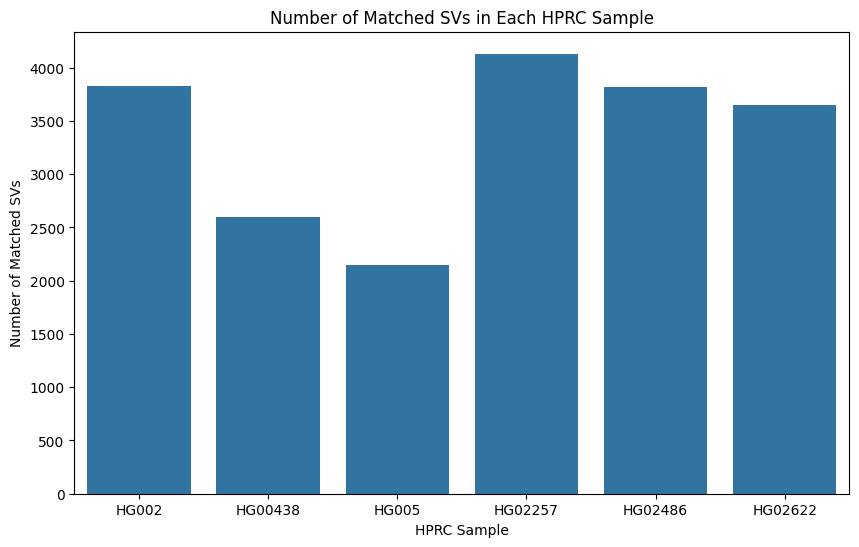

In [ ]:
# Count the number of matched SVs in each HPRC sample
matched_sv_counts = [len(df) for df in hprc_sv_matched_df_list]
sample_names = hprc_sample_list
# Create a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=sample_names, y=matched_sv_counts)
plt.xlabel('HPRC Sample')
plt.ylabel('Number of Matched SVs')
plt.title('Number of Matched SVs in Each HPRC Sample')
plt.show()

In [56]:
# uncomment to get the benchmarking results
# truvari bench -b ./dataset/assembly_based_sv_distinct_heterozygous.vcf.gz -c ./dataset/hapmap_smaht_ont_mosaic.vcf.gz -o ./dataset/assembly_based_sv_distinct_heterozygous_bench_hapmap  --pctseq 0.9 --pctsize 0.9 --passonly

In [58]:
hprc_sv_matched_df_total = pd.concat(hprc_sv_matched_df_list, axis=0).reset_index(drop=True)
final_matched_hprc_sv_df = hprc_sv_matched_df_total[(abs(hprc_sv_matched_df_total['sv_len']) > 100) & (hprc_sv_matched_df_total['stdev_len'] < 10) & (hprc_sv_matched_df_total['stdev_pos'] < 10)].sort_values("id_asm")

In [60]:
hapmap_hetero_confirmed_sv = "dataset/assembly_based_sv_distinct_heterozygous_bench_hapmap/tp-comp.vcf.gz"
hapmap_hetero_confirmed_sv_df = read_vcf_to_df(pysam.VariantFile(hapmap_hetero_confirmed_sv))
hprc_hapmap_hetero_confirmed_sv = "dataset/assembly_based_sv_distinct_heterozygous_bench_hapmap/tp-base.vcf.gz"
hprc_hapmap_hetero_confirmed_sv_df = read_vcf_to_df_comp(pysam.VariantFile(hprc_hapmap_hetero_confirmed_sv))
hetro_hapmap_benchmark_list = pd.concat([hapmap_hetero_confirmed_sv_df, hprc_hapmap_hetero_confirmed_sv_df.add_suffix("_asm")], axis=1)

In [64]:
hetro_hapmap_benchmark_list

,chr,location,id,sv_len,supporting_reads,stdev_len,stdev_pos,ref_start,ref_end,chr_asm,location_asm,id_asm,sv_len_asm,sample_name_asm
0,chr1,711979,Sniffles2.DEL.2195S0,-90,"(27c14a23-3b4d-49f6-a7dd-0fd28369fac5, f849656...",0.000,0.000000,711979,712069,chr1,711958,HapMapBench.00000006,-90,HG02622
1,chr1,814584,Sniffles2.INS.46S0,103,"(864934f6-da58-4e53-a52e-e9d5e5b183ea, 05d3dfc...",2.317,12.656000,814571,814598,chr1,814549,HapMapBench.00000021,99,HG02257
2,chr1,868472,Sniffles2.INS.4BS0,2523,"(3dfef383-e3cb-4a92-be93-92a3aec61064, 3c24025...",1.414,0.707000,868471,868474,chr1,868470,HapMapBench.00000026,2559,HG00438
3,chr1,904657,Sniffles2.INS.52S0,355,"(fbce6b2f-67ca-4c2f-a66f-0d6e1ae2930e, 54d1278...",1.517,0.000000,904657,904658,chr1,904656,HapMapBench.00000031,354,HG02622
4,chr1,934055,Sniffles2.DEL.21BBS0,-307,"(9ce33956-9322-42b4-ba60-14c5916c340c, 13e33a1...",11.971,27.253000,934027,934401,chr1,933961,HapMapBench.00000037,-280,HG02622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6008,chr22,50405558,Sniffles2.DEL.1913S15,-58,"(87ffb65c-a847-497b-851d-f6c366742952, 590fe90...",0.516,21.566999,50405536,50405638,chr22,50405556,HapMapBench.00106422,-59,HG005
6009,chr22,50521320,Sniffles2.DEL.191FS15,-65,"(201690d4-4bc5-4ebc-878e-5287f2b1629a, 51492bd...",0.000,0.000000,50521320,50521385,chr22,50521319,HapMapBench.00106454,-65,HG02257
6010,chr22,50608338,Sniffles2.INS.8FAS15,57,"(2a1abb42-5c28-4f8f-84e5-bdf220826d43, f2aa744...",0.447,0.000000,50608338,50608338,chr22,50608337,HapMapBench.00106458,57,HG02622
6011,chr22,50685534,Sniffles2.DEL.1934S15,-148,"(5c43ddbd-092f-47ce-83af-7e32590a5f8d, 01a3448...",0.447,20.354000,50685513,50685702,chr22,50685533,HapMapBench.00106492,-148,HG02622


In [62]:
all_final_checks_df = pd.merge(hetro_hapmap_benchmark_list, final_matched_hprc_sv_df, suffixes=('_hapmap', '_hprc'), on='id_asm')

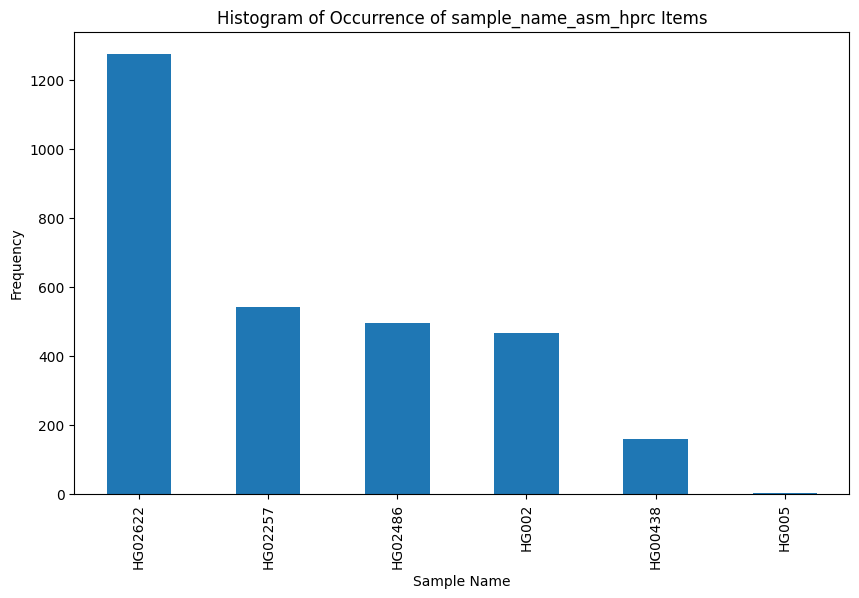

In [66]:
plt.figure(figsize=(10, 6))
all_final_checks_df['sample_name_asm_hprc'].value_counts().plot(kind='bar')
plt.xlabel('Sample Name')
plt.ylabel('Frequency')
plt.title('Histogram of Occurrence of sample_name_asm_hprc Items')
plt.show()